In [1]:
using VeryDiff, LinearAlgebra, Plots 
using VeryDiff: LayeredModel, to_layered_model, ONNXChebyshevPoly
import VeryDiff: approximate_polynomial_iterative, approximate_polynomial_iterative_sampling, approximate_polynomial_abcrown

using VNNLib
const OXP = VNNLib.OnnxParser

using VeryDiffPolyExperiments
using VeryDiffPolyExperiments: generate_poly_network, convert_to_list_of_tuples, merge_normalization_into_dense

Set parameter Username
Set parameter LicenseID to value 2751365
Academic license - for non-commercial use only - expires 2026-12-08


**TODO**:
- make abcrown work with not only `[0,1]` bounds!
- are we using the verified polynomial approximation???

In [2]:
using VeryDiffPolyExperiments: load_mnist_data, acc_fun, max_fun, mae_fun, mse_fun, evaluate_network

VeryDiff.ALMOST_ZERO_LEADING_COEFF_WARNING[] = false

false

In [3]:
X_test, y_labels = load_mnist_data()
y_labels = y_labels .+ 1;  # convert to 1-based indexing

In [38]:
function compute_approximation_stats(onnx_path, degrees; max_polys_per_layer=1, max_iter=0, verbosity=0, mode=:zono)
    onnx_model = load_onnx_model(onnx_path)
    nn = to_layered_model(onnx_model)

    ŷ = [nn(x) for x in X_test]
    ŷ = hcat(ŷ...)'
    original_acc = acc_fun(y_labels, ŷ)
    println("Original accuracy: $original_acc")

    max_errs_single = []
    maes_single = []
    mses_single = []
    accs_single = []

    for d in degrees
        if mode == :sampling
            nn_poly = approximate_polynomial_iterative_sampling(nn, X_test, d, max_polys_per_layer=max_polys_per_layer, verbosity=verbosity, max_iter=max_iter)
        elseif mode == :abcrown 
            nn_poly = approximate_polynomial_abcrown(onnx_path, d, max_polys_per_layer=max_polys_per_layer, max_iter=max_iter, verbosity=verbosity);
        elseif mode == :zono
            nn_poly = approximate_polynomial_iterative(nn, Zonotope(zeros(784), ones(784)), d, max_polys_per_layer=max_polys_per_layer, verbosity=verbosity, max_iter=max_iter)
        else 
            @assert false "unknown mode $mode"
        end
        max_err, mae, mse, acc, _ = evaluate_network(nn_poly, X_test, ŷ, y_labels, max_fun, mae_fun, mse_fun, acc_fun)
        push!(max_errs_single, max_err)
        push!(maes_single, mae)
        push!(mses_single, mse)
        push!(accs_single, acc)
        println("Degree $d: max err = $max_err, mae = $mae, mse = $mse, acc = $acc")
    end

    return max_errs_single, maes_single, mses_single, accs_single
end

compute_approximation_stats (generic function with 1 method)

# MNIST

## MNIST 1e-4

In [ ]:
degrees = 1:15
max_polys_per_layer = Inf
max_iter=20

result_dict = Dict();

### GeLU

In [41]:
onnx_path = "../networks/mnist/mnist_gelu_256x4_1e4.onnx"

"../networks/mnist/mnist_gelu_256x4_1e4.onnx"

In [6]:
mode = :abcrown
max_errs, maes, mses, accs = compute_approximation_stats(onnx_path, degrees; max_polys_per_layer=max_polys_per_layer, max_iter=max_iter, mode=mode)
result_dict["gelu_1e4_abcrown"] = (max_errs=max_errs, maes=maes, mses=mses, accs=accs)

┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Original accuracy: 0.9893


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Degree 1: max err = 85.61560201589566, mae = 70.4568109519362, mse = 19672.101582907748, acc = 0.10441666666666667
Degree 2: max err = 25.029373515053717, mae = 14.154413687154873, mse = 405.27365994868825, acc = 0.3993833333333333


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


...

Degree 14: max err = 4.1340602218449645, mae = 2.0569959125831483, mse = 9.438167062745606, acc = 0.9875833333333334


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Degree 15: max err = 3.742823538355621, mae = 1.783008621221504, mse = 7.459192664185879, acc = 0.9877666666666667


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


(max_errs = Any[85.61560201589566, 25.029373515053717, 22.47370693079979, 17.388459025974335, 13.874775533967531, 12.241855666296445, 9.97889019415491, 8.627010907010277, 7.717503331784789, 6.67732072106238, 6.045435847437062, 5.299775068519201, 4.734449209372436, 4.1340602218449645, 3.742823538355621], maes = Any[70.4568109519362, 14.154413687154873, 11.733171818456182, 9.741200108912219, 8.452221382492937, 7.348568417684932, 6.306581286261295, 5.41791402213957, 4.757962905511838, 4.032737234110232, 3.42833507553905, 2.9134198859018583, 2.445493316897426, 2.0569959125831483, 1.783008621221504], mses = Any[19672.101582907748, 405.27365994868825, 233.40972031778196, 141.26085057691327, 108.55725399600733, 85.17214396618776, 64.20423933074375, 49.940221248050776, 39.670703907073325, 29.869085826305177, 22.662942033243045, 17.162410096801732, 12.76822036113087, 9.438167062745606, 7.459192664185879], accs = Any[0.10441666666666667, 0.3993833333333333, 0.42311666666666664, 0.880466666666666

In [42]:
mode = :zono
max_errs, maes, mses, accs = compute_approximation_stats(onnx_path, degrees; max_polys_per_layer=max_polys_per_layer, max_iter=max_iter, mode=mode)
result_dict["gelu_1e4_zono"] = (max_errs=max_errs, maes=maes, mses=mses, accs=accs)

┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Original accuracy: 0.9893
Degree 1: max err = 26.51947121073937, mae = 15.329220882875056, mse = 601.4143073893356, acc = 0.25345
Degree 2: max err = 25.90911864651872, mae = 14.067371391964455, mse = 394.7693906395015, acc = 0.2506333333333333
Degree 3: max err = 25.706265319081073, mae = 13.446285554281529, mse = 336.13564188509116, acc = 0.37225
Degree 4: max err = 20.753748743866467, mae = 11.225283750223625, mse = 195.4201475474756, acc = 0.7075166666666667
Degree 5: max err = 17.99709378548304, mae = 9.904024180614089, mse = 148.48549972051023, acc = 0.8436
Degree 6: max err = 16.118692919846698, mae = 9.363853725647418, mse = 129.78638981372475, acc = 0.9196333333333333
Degree 7: max err = 15.042440141297066, mae = 8.84325118793203, mse = 118.32143359841005, acc = 0.9346666666666666
Degree 8: max err = 13.187263855185794, mae = 8.248219982229967, mse = 102.62408718762046, acc = 0.9625666666666667
Degree 9: max err = 11.652579834247057, mae = 7.617125439218999, mse = 90.336674610

(max_errs = Any[26.51947121073937, 25.90911864651872, 25.706265319081073, 20.753748743866467, 17.99709378548304, 16.118692919846698, 15.042440141297066, 13.187263855185794, 11.652579834247057, 10.86213601902944, 9.958900015509325, 9.252055207394566, 8.579951152614811, 7.795976439431765, 7.372995342592423], maes = Any[15.329220882875056, 14.067371391964455, 13.446285554281529, 11.225283750223625, 9.904024180614089, 9.363853725647418, 8.84325118793203, 8.248219982229967, 7.617125439218999, 7.201407662193228, 6.711399265658303, 6.297891790350733, 5.857601873218937, 5.374345628757334, 5.037895679740218], mses = Any[601.4143073893356, 394.7693906395015, 336.13564188509116, 195.4201475474756, 148.48549972051023, 129.78638981372475, 118.32143359841005, 102.62408718762046, 90.3366746103035, 81.47888188572429, 72.15341948065458, 64.81580131078027, 57.29445600707618, 49.52419730793476, 44.48821573639786], accs = Any[0.25345, 0.2506333333333333, 0.37225, 0.7075166666666667, 0.8436, 0.919633333333

In [44]:
mode = :sampling
max_errs, maes, mses, accs = compute_approximation_stats(onnx_path, degrees; max_polys_per_layer=max_polys_per_layer, max_iter=max_iter, mode=mode)
result_dict["gelu_1e4_sampling"] = (max_errs=max_errs, maes=maes, mses=mses, accs=accs)

Original accuracy: 0.9893


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Degree 1: max err = 23.077452290275502, mae = 11.24083581165399, mse = 311.36265132316373, acc = 0.2972
Degree 2: max err = 13.36603251834931, mae = 6.205144700846288, mse = 80.61173873311049, acc = 0.8598666666666667
Degree 3: max err = 10.057958603284856, mae = 3.87995325850409, mse = 35.104449267623664, acc = 0.9488666666666666
Degree 4: max err = 6.880754521384946, mae = 1.9672029740926607, mse = 10.991019065306851, acc = 0.9767666666666667
Degree 5: max err = 4.259956030952161, mae = 1.0428465420576192, mse = 3.250004851043497, acc = 0.9837833333333333
Degree 6: max err = 2.864208910664603, mae = 0.6574964011107008, mse = 1.301172560175364, acc = 0.9870166666666667
Degree 7: max err = 1.87501006521721, mae = 0.40000000026430726, mse = 0.4829853644862502, acc = 0.9880166666666667
Degree 8: max err = 1.059513555200783, mae = 0.22562899664629915, mse = 0.15245410510154342, acc = 0.9887666666666667
Degree 9: max err = 0.6518192956742617, mae = 0.15809039675053713, mse = 0.075282077785

(max_errs = Any[23.077452290275502, 13.36603251834931, 10.057958603284856, 6.880754521384946, 4.259956030952161, 2.864208910664603, 1.87501006521721, 1.059513555200783, 0.6518192956742617, 0.41575558286571224, 0.24440850804297765, 0.17316846218831428, 0.07342966097464743, 0.05559400397913805, 0.02984843987105057], maes = Any[11.24083581165399, 6.205144700846288, 3.87995325850409, 1.9672029740926607, 1.0428465420576192, 0.6574964011107008, 0.40000000026430726, 0.22562899664629915, 0.15809039675053713, 0.09119372559688016, 0.05806733334214634, 0.038719312394930525, 0.019614418855281653, 0.015319906378367023, 0.008446521728754708], mses = Any[311.36265132316373, 80.61173873311049, 35.104449267623664, 10.991019065306851, 3.250004851043497, 1.301172560175364, 0.4829853644862502, 0.15245410510154342, 0.07528207778584614, 0.025319276994061564, 0.010279933257790351, 0.004603999790067371, 0.0011715956350109513, 0.0007295206557353949, 0.00022040491920855161], accs = Any[0.2972, 0.859866666666666

In [45]:
result_dict

Dict{Any, Any} with 5 entries:
  "relu_1e4_zono"     => (max_errs = Any[26.0064, 12.5764, 9.30187, 6.27545, 4.…
  "relu_1e4_abcrown"  => (max_errs = Any[125.519, 29.7962, 19.582, 14.5694, 12.…
  "gelu_1e4_sampling" => (max_errs = Any[23.0775, 13.366, 10.058, 6.88075, 4.25…
  "gelu_1e4_abcrown"  => (max_errs = Any[85.6156, 25.0294, 22.4737, 17.3885, 13…
  "gelu_1e4_zono"     => (max_errs = Any[26.5195, 25.9091, 25.7063, 20.7537, 17…

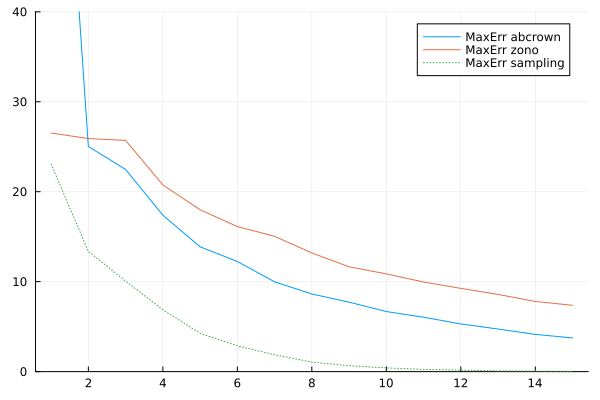

In [52]:
plot(degrees, result_dict["gelu_1e4_abcrown"].max_errs, label="MaxErr abcrown")
plot!(degrees, result_dict["gelu_1e4_zono"].max_errs, label="MaxErr zono")
plot!(degrees, result_dict["gelu_1e4_sampling"].max_errs, label="MaxErr sampling", linestyle=:dot)
ylims!(0, 40)

### ReLU

In [47]:
onnx_path = "../networks/mnist/mnist_256x4_1e4.onnx"

"../networks/mnist/mnist_256x4_1e4.onnx"

In [11]:
mode = :abcrown
max_errs, maes, mses, accs = compute_approximation_stats(onnx_path, degrees; max_polys_per_layer=max_polys_per_layer, max_iter=max_iter, mode=mode)
result_dict["relu_1e4_abcrown"] = (max_errs=max_errs, maes=maes, mses=mses, accs=accs)

Original accuracy: 0.9864166666666667


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Degree 1: max err = 125.51943594874413, mae = 114.49785127462329, mse = 59034.335563450295, acc = 0.10441666666666667


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Degree 2: max err = 29.796197139115204, mae = 20.175773902708595, mse = 1343.143778634591, acc = 0.14685


...

Degree 14: max err = 4.712275761681742, mae = 2.0695276973575263, mse = 12.911145752651706, acc = 0.9825666666666667


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Degree 15: max err = 4.251635618947201, mae = 1.7982353474587882, mse = 9.9563441733462, acc = 0.98305


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


(max_errs = Any[125.51943594874413, 29.796197139115204, 19.582007322074997, 14.569400735057938, 12.151954297467636, 10.582886038723625, 9.148457638545242, 8.576016012801452, 7.291224979783772, 6.432471380932601, 5.9358713660758635, 5.554038363118343, 5.108343667344774, 4.712275761681742, 4.251635618947201], maes = Any[114.49785127462329, 20.175773902708595, 12.806602257694243, 9.710993144117742, 8.025218392377102, 6.918936571917745, 5.902049848188483, 5.0946884772882495, 4.391610351887061, 3.767523621658484, 3.2217811235890306, 2.81574496461951, 2.3888340480019337, 2.0695276973575263, 1.7982353474587882], mses = Any[59034.335563450295, 1343.143778634591, 364.7886623987944, 172.49663932782207, 122.23314409088809, 98.13970511075358, 78.53300072587626, 62.9666632507918, 49.059099850670776, 37.93572842476084, 28.664763155050785, 22.6739409049651, 16.798721759168412, 12.911145752651706, 9.9563441733462], accs = Any[0.10441666666666667, 0.14685, 0.4444666666666667, 0.7643666666666666, 0.9085

In [48]:
mode = :zono
max_errs, maes, mses, accs = compute_approximation_stats(onnx_path, degrees; max_polys_per_layer=max_polys_per_layer, max_iter=max_iter, mode=mode)
result_dict["relu_1e4_zono"] = (max_errs=max_errs, maes=maes, mses=mses, accs=accs)

┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Original accuracy: 0.9864166666666667
Degree 1: max err = 43.955367067967316, mae = 31.06429666762878, mse = 3152.460283141473, acc = 0.17158333333333334
Degree 2: max err = 28.89065820938184, mae = 19.61944470693981, mse = 1210.4756963066732, acc = 0.15133333333333332
Degree 3: max err = 22.61390879134009, mae = 14.767355138420573, mse = 554.612221877655, acc = 0.3928333333333333
Degree 4: max err = 17.711996124257354, mae = 11.821677675298773, mse = 277.8573305405739, acc = 0.4567
Degree 5: max err = 14.565118933588106, mae = 9.732071775379847, mse = 169.02939916986924, acc = 0.8107666666666666
Degree 6: max err = 13.382270757315524, mae = 9.051182813309412, mse = 148.00481018325638, acc = 0.8269333333333333
Degree 7: max err = 12.334020741407578, mae = 8.266187887981992, mse = 125.19478368998227, acc = 0.9091166666666667
Degree 8: max err = 11.256163960508982, mae = 7.385372856472827, mse = 105.74997743300287, acc = 0.9384333333333333
Degree 9: max err = 10.262942504041334, mae = 6.

(max_errs = Any[43.955367067967316, 28.89065820938184, 22.61390879134009, 17.711996124257354, 14.565118933588106, 13.382270757315524, 12.334020741407578, 11.256163960508982, 10.262942504041334, 9.713366902171714, 9.337302757666244, 9.163041763908376, 8.468455288227318, 7.70578610472753, 6.872182483622675], maes = Any[31.06429666762878, 19.61944470693981, 14.767355138420573, 11.821677675298773, 9.732071775379847, 9.051182813309412, 8.266187887981992, 7.385372856472827, 6.670632534330955, 6.139376503122245, 5.584787187515195, 5.15818631717199, 4.712457997883497, 4.300897896800729, 3.9417190768686674], mses = Any[3152.460283141473, 1210.4756963066732, 554.612221877655, 277.8573305405739, 169.02939916986924, 148.00481018325638, 125.19478368998227, 105.74997743300287, 90.78160932428247, 80.22175126829819, 69.80301688984508, 61.72746811139728, 53.50913480028665, 46.199323668623734, 39.842657766334256], accs = Any[0.17158333333333334, 0.15133333333333332, 0.3928333333333333, 0.4567, 0.8107666

In [49]:
mode = :sampling
max_errs, maes, mses, accs = compute_approximation_stats(onnx_path, degrees; max_polys_per_layer=max_polys_per_layer, max_iter=max_iter, mode=mode)
result_dict["relu_1e4_sampling"] = (max_errs=max_errs, maes=maes, mses=mses, accs=accs)

Original accuracy: 0.9864166666666667


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Degree 1: max err = 26.006384459084522, mae = 14.42347746284934, mse = 624.1409951488691, acc = 0.26708333333333334
Degree 2: max err = 12.576386480766903, mae = 5.878395580041952, mse = 101.89405313240236, acc = 0.8701
Degree 3: max err = 9.301873063757736, mae = 3.9316811831698812, mse = 53.62934962330042, acc = 0.9553833333333334
Degree 4: max err = 6.275449517017796, mae = 2.3599168366433747, mse = 19.324914820831236, acc = 0.9701
Degree 5: max err = 4.753547672822248, mae = 1.4509767289278428, mse = 7.134287764670054, acc = 0.9777166666666667
Degree 6: max err = 4.63762619209853, mae = 1.1962367720105103, mse = 4.784406776910042, acc = 0.9796166666666667
Degree 7: max err = 3.6988367681472467, mae = 0.9641866854484706, mse = 3.1358399584287597, acc = 0.98215
Degree 8: max err = 3.3383496385180926, mae = 0.8206459433279436, mse = 2.307975129515132, acc = 0.98355
Degree 9: max err = 2.7163053791842806, mae = 0.736267101796063, mse = 1.8596510483443403, acc = 0.9844166666666667
Degre

(max_errs = Any[26.006384459084522, 12.576386480766903, 9.301873063757736, 6.275449517017796, 4.753547672822248, 4.63762619209853, 3.6988367681472467, 3.3383496385180926, 2.7163053791842806, 2.7422362290539164, 2.702975314627121, 2.103672167462455, 1.7071937175938467, 1.5601111436680482, 1.4003929049431783], maes = Any[14.42347746284934, 5.878395580041952, 3.9316811831698812, 2.3599168366433747, 1.4509767289278428, 1.1962367720105103, 0.9641866854484706, 0.8206459433279436, 0.736267101796063, 0.6257171859605669, 0.5670364407785947, 0.5074737950101663, 0.46129108927879703, 0.4215914698208304, 0.38927332905277134], mses = Any[624.1409951488691, 101.89405313240236, 53.62934962330042, 19.324914820831236, 7.134287764670054, 4.784406776910042, 3.1358399584287597, 2.307975129515132, 1.8596510483443403, 1.3564234562943136, 1.1107980209720631, 0.8912227391205518, 0.7282399458170942, 0.6040245462580636, 0.5153357235786028], accs = Any[0.26708333333333334, 0.8701, 0.9553833333333334, 0.9701, 0.97

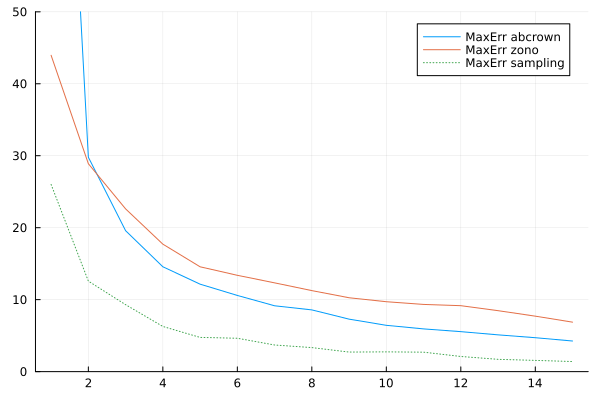

In [51]:
plot(degrees, result_dict["relu_1e4_abcrown"].max_errs, label="MaxErr abcrown")
plot!(degrees, result_dict["relu_1e4_zono"].max_errs, label="MaxErr zono")
plot!(degrees, result_dict["relu_1e4_sampling"].max_errs, label="MaxErr sampling", linestyle=:dot)
ylims!(0, 50)

### Compare ReLU vs GeLU

In [85]:
degrees = 1:15

1:15

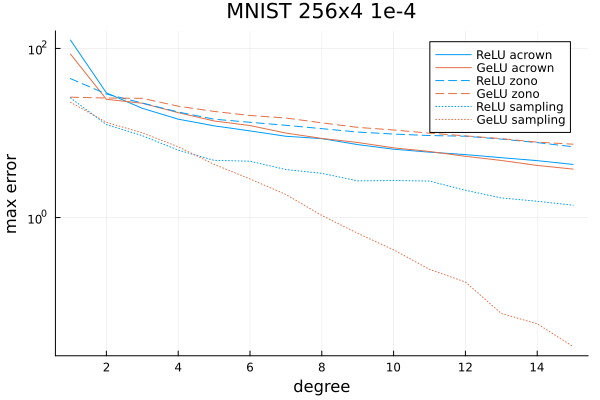

In [92]:
plot(degrees, result_dict["relu_1e4_abcrown"].max_errs, label="ReLU acrown", color=1, yscale=:log10, xlabel="degree", ylabel="max error", title="MNIST 256x4 1e-4")
plot!(degrees, result_dict["gelu_1e4_abcrown"].max_errs, label="GeLU acrown", color=2)

plot!(degrees, result_dict["relu_1e4_zono"].max_errs, label="ReLU zono", color=1, linestyle=:dash)
plot!(degrees, result_dict["gelu_1e4_zono"].max_errs, label="GeLU zono", color=2, linestyle=:dash)

plot!(degrees, result_dict["relu_1e4_sampling"].max_errs, label="ReLU sampling", color=1, linestyle=:dot)
plot!(degrees, result_dict["gelu_1e4_sampling"].max_errs, label="GeLU sampling", color=2, linestyle=:dot)
# ylims!(0, 40)

We see a better progress in the maximum error for the GeLU network with sampled bounds (tightest possible - but in practice not obtainable solution).
- We can get closer to sampled bounds by splitting
- We can hope that with higher degree we see the same progression

## MNIST 2e-5

In [58]:
degrees = 1:25

1:25

### GeLU

In [59]:
onnx_path = "../networks/mnist/mnist_gelu_256x4_2e5.onnx"

"../networks/mnist/mnist_gelu_256x4_2e5.onnx"

In [63]:
mode = :abcrown
max_errs, maes, mses, accs = compute_approximation_stats(onnx_path, degrees; max_polys_per_layer=max_polys_per_layer, max_iter=max_iter, mode=mode)
result_dict["gelu_2e5_abcrown"] = (max_errs=max_errs, maes=maes, mses=mses, accs=accs)

Original accuracy: 0.9936


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Degree 1: max err = 396.48188190568214, mae = 375.2849890822372, mse = 865103.6728604838, acc = 0.10441666666666667


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Degree 2: max err = 64.55114282334432, mae = 49.49951247464201, mse = 10153.359524004705, acc = 0.2796666666666667


...

Degree 24: max err = 5.552224234836866, mae = 2.57148285790625, mse = 13.693798030794534, acc = 0.9917833333333334


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Degree 25: max err = 5.247419045184193, mae = 2.3791900019256524, mse = 12.088841394538852, acc = 0.9919


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


(max_errs = Any[396.48188190568214, 64.55114282334432, 42.799073655790515, 29.29512817015734, 23.840383593691097, 20.578223475450468, 17.888397214735345, 16.05156643167295, 14.373713347734295, 13.238542767828157  …  8.592478512207812, 8.056507253911615, 7.63391448035938, 7.245540917503032, 6.8631498730336755, 6.503694197096426, 6.11881855929562, 5.848559268287687, 5.552224234836866, 5.247419045184193], maes = Any[375.2849890822372, 49.49951247464201, 29.276726295227466, 20.053807537118338, 16.11746574979233, 13.506925779279658, 11.56760752937249, 10.411376209669037, 9.309005137622352, 8.502805926436029  …  5.070002655522626, 4.622476372643141, 4.253349314397884, 3.9190007321881195, 3.599805932311638, 3.3150744934123106, 3.0338000448215268, 2.80526683973826, 2.57148285790625, 2.3791900019256524], mses = Any[865103.6728604838, 10153.359524004705, 3904.529861741381, 1347.2689167784515, 681.1782376728814, 396.07580796192684, 249.12433064325734, 182.99228566378778, 137.20986057912776, 109.9

In [64]:
mode = :zono
max_errs, maes, mses, accs = compute_approximation_stats(onnx_path, degrees; max_polys_per_layer=max_polys_per_layer, max_iter=max_iter, mode=mode)
result_dict["gelu_2e5_zono"] = (max_errs=max_errs, maes=maes, mses=mses, accs=accs)

Original accuracy: 0.9936


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Degree 1: max err = 47.61832246840956, mae = 30.482663791018272, mse = 2290.950726217945, acc = 0.20443333333333333
Degree 2: max err = 55.762831738877566, mae = 41.20975312772799, mse = 6826.53159724161, acc = 0.2334
Degree 3: max err = 52.55830278512763, mae = 38.0023587764424, mse = 7650.6620325931535, acc = 0.4261666666666667
Degree 4: max err = 36.239728031787365, mae = 26.225048326811194, mse = 2806.6536640559552, acc = 0.44631666666666664
Degree 5: max err = 29.179309695171668, mae = 20.106840389848617, mse = 1357.2608222192773, acc = 0.6824833333333333
Degree 6: max err = 26.26932544827129, mae = 18.30226018636415, mse = 1035.5289980599387, acc = 0.6901666666666667
Degree 7: max err = 24.820464102040408, mae = 17.0848781573821, mse = 846.7690662538639, acc = 0.7915
Degree 8: max err = 22.3189547284604, mae = 15.380806269977539, mse = 609.3371009412488, acc = 0.8127333333333333
Degree 9: max err = 20.07147721698714, mae = 13.811748414699489, mse = 434.8152800776835, acc = 0.8928

(max_errs = Any[47.61832246840956, 55.762831738877566, 52.55830278512763, 36.239728031787365, 29.179309695171668, 26.26932544827129, 24.820464102040408, 22.3189547284604, 20.07147721698714, 18.75524570748002  …  13.140951050061963, 12.477730336636206, 11.96261699202618, 11.483032816509928, 11.006477447018653, 10.609969076780425, 10.191033123581127, 9.920721183940891, 9.623318841312347, 9.312490010399134], maes = Any[30.482663791018272, 41.20975312772799, 38.0023587764424, 26.225048326811194, 20.106840389848617, 18.30226018636415, 17.0848781573821, 15.380806269977539, 13.811748414699489, 12.812553903372411  …  9.300328214124896, 8.864982967783938, 8.471342239167488, 8.08806245146731, 7.729523334332986, 7.433497267832087, 7.103906629374351, 6.7626408726308265, 6.5267667609936675, 6.203502500940182], mses = Any[2290.950726217945, 6826.53159724161, 7650.6620325931535, 2806.6536640559552, 1357.2608222192773, 1035.5289980599387, 846.7690662538639, 609.3371009412488, 434.8152800776835, 341.25

In [65]:
mode = :sampling
max_errs, maes, mses, accs = compute_approximation_stats(onnx_path, degrees; max_polys_per_layer=max_polys_per_layer, max_iter=max_iter, mode=mode)
result_dict["gelu_2e5_sampling"] = (max_errs=max_errs, maes=maes, mses=mses, accs=accs)

Original accuracy: 0.9936


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Degree 1: max err = 28.228121544088427, mae = 14.596405107946776, mse = 506.3672816198804, acc = 0.27841666666666665
Degree 2: max err = 15.59241583006996, mae = 7.086062038283834, mse = 104.24395981652069, acc = 0.8648333333333333
Degree 3: max err = 12.351686392753859, mae = 4.537946225608853, mse = 54.857841200688824, acc = 0.9437166666666666
Degree 4: max err = 9.215530101017483, mae = 2.558526625946165, mse = 20.13884620219808, acc = 0.9794166666666667
Degree 5: max err = 6.345645801224109, mae = 1.5733077213363154, mse = 8.375829107919452, acc = 0.9878333333333333
Degree 6: max err = 4.689709575607651, mae = 1.0530694845588662, mse = 3.897922760825928, acc = 0.99075
Degree 7: max err = 3.3465618089942324, mae = 0.7238449328205931, mse = 1.8829794761448384, acc = 0.9923
Degree 8: max err = 2.576110382459825, mae = 0.5002011109786089, mse = 0.8978490833673466, acc = 0.9931333333333333
Degree 9: max err = 1.7773261443363149, mae = 0.37134721381178093, mse = 0.49761694928583555, acc 

(max_errs = Any[28.228121544088427, 15.59241583006996, 12.351686392753859, 9.215530101017483, 6.345645801224109, 4.689709575607651, 3.3465618089942324, 2.576110382459825, 1.7773261443363149, 1.304297668630027  …  0.22394834195699875, 0.18836402893929804, 0.13085018389094083, 0.09427167815244708, 0.06790009452113077, 0.04777990808643162, 0.03326543272504523, 0.022285628791574474, 0.015260434984146531, 0.011499721596510248], maes = Any[14.596405107946776, 7.086062038283834, 4.537946225608853, 2.558526625946165, 1.5733077213363154, 1.0530694845588662, 0.7238449328205931, 0.5002011109786089, 0.37134721381178093, 0.26586265314441004  …  0.04053117751989598, 0.030067862297199714, 0.021951775144567257, 0.014960388711544866, 0.011384868998422523, 0.007770135607307981, 0.0056892314325440434, 0.004040616266749911, 0.0027188509761711488, 0.001996770599420653], mses = Any[506.3672816198804, 104.24395981652069, 54.857841200688824, 20.13884620219808, 8.375829107919452, 3.897922760825928, 1.882979476

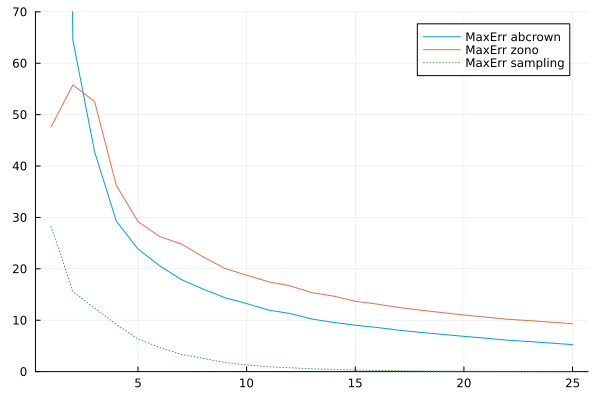

In [72]:
plot(degrees, result_dict["gelu_2e5_abcrown"].max_errs, label="MaxErr abcrown")
plot!(degrees, result_dict["gelu_2e5_zono"].max_errs, label="MaxErr zono")
plot!(degrees, result_dict["gelu_2e5_sampling"].max_errs, label="MaxErr sampling", linestyle=:dot)
ylims!(0, 70)

### ReLU

In [66]:
onnx_path = "../networks/mnist/mnist_256x4_2e5.onnx"

"../networks/mnist/mnist_256x4_2e5.onnx"

In [67]:
mode = :abcrown
max_errs, maes, mses, accs = compute_approximation_stats(onnx_path, degrees; max_polys_per_layer=max_polys_per_layer, max_iter=max_iter, mode=mode)
result_dict["relu_2e5_abcrown"] = (max_errs=max_errs, maes=maes, mses=mses, accs=accs)

Original accuracy: 0.9940333333333333


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Degree 1: max err = 537.6520137819955, mae = 516.4817314070233, mse = 1.3273598240489326e6, acc = 0.09035


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Degree 2: max err = 73.73816171189003, mae = 57.71792774810305, mse = 17033.790993838673, acc = 0.19368333333333335


...

Degree 24: max err = 6.027013546532057, mae = 3.156160220800282, mse = 23.10105095673385, acc = 0.9918666666666667


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Degree 25: max err = 5.67862248506823, mae = 2.9586095917242288, mse = 20.900702114202563, acc = 0.9923166666666666


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


(max_errs = Any[537.6520137819955, 73.73816171189003, 51.77783677268131, 34.27860241690389, 27.937110235552005, 22.031705535158967, 19.01417620512826, 16.48098241063052, 14.45302656566516, 13.078113799013853  …  9.05486716676459, 8.48844675672513, 8.133985779984094, 7.438493971773094, 7.052919559402948, 6.680580128294364, 6.4830427924544, 6.294007539355647, 6.027013546532057, 5.67862248506823], maes = Any[516.4817314070233, 57.71792774810305, 36.80054750910642, 22.992827850072583, 18.00868513082439, 14.498954742513023, 12.372723187610694, 10.916211514199098, 9.612930976658376, 8.769756205032731  …  5.408561249506204, 5.005961832132445, 4.703490646337652, 4.340673524717012, 4.093065134040125, 3.830961094034097, 3.5894064140338333, 3.3360639867496986, 3.156160220800282, 2.9586095917242288], mses = Any[1.3273598240489326e6, 17033.790993838673, 6190.144034042128, 2147.572582630177, 1077.2704918941388, 566.3368947763731, 348.8137749762405, 240.44115721540481, 167.1292586439129, 130.15013449

In [68]:
mode = :zono
max_errs, maes, mses, accs = compute_approximation_stats(onnx_path, degrees; max_polys_per_layer=max_polys_per_layer, max_iter=max_iter, mode=mode)
result_dict["relu_2e5_zono"] = (max_errs=max_errs, maes=maes, mses=mses, accs=accs)

Original accuracy: 0.9940333333333333


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Degree 1: max err = 58.41091381468089, mae = 40.88451895852713, mse = 6099.94937634237, acc = 0.16326666666666667
Degree 2: max err = 65.06659155668571, mae = 48.7859451994624, mse = 11649.734324915424, acc = 0.18975
Degree 3: max err = 62.33493940129159, mae = 46.601507085411356, mse = 11102.05057757866, acc = 0.15785
Degree 4: max err = 41.96972695475998, mae = 29.59117706436862, mse = 4007.751473019956, acc = 0.2891166666666667
Degree 5: max err = 31.443553289644647, mae = 21.61280038418884, mse = 1805.5267605932543, acc = 0.5206833333333334
Degree 6: max err = 29.34573753769866, mae = 20.057414575399417, mse = 1482.452215703299, acc = 0.4724
Degree 7: max err = 26.36263152031483, mae = 18.184855641061855, mse = 1131.0904218574096, acc = 0.6633166666666667
Degree 8: max err = 23.157275177821848, mae = 15.965248700102663, mse = 770.2237876104491, acc = 0.7365
Degree 9: max err = 20.62378331138865, mae = 14.279074946522321, mse = 547.9956505888913, acc = 0.80335
Degree 10: max err = 1

(max_errs = Any[58.41091381468089, 65.06659155668571, 62.33493940129159, 41.96972695475998, 31.443553289644647, 29.34573753769866, 26.36263152031483, 23.157275177821848, 20.62378331138865, 18.72215162421055  …  12.974516728432153, 12.539174541640683, 12.068158432140056, 11.615453277407413, 11.058223273690281, 10.6435034682941, 10.139775336908176, 9.799457439874427, 9.486226503477004, 9.147448876280146], maes = Any[40.88451895852713, 48.7859451994624, 46.601507085411356, 29.59117706436862, 21.61280038418884, 20.057414575399417, 18.184855641061855, 15.965248700102663, 14.279074946522321, 13.043963629093227  …  9.175339423400024, 8.702107523578775, 8.338675579633453, 7.958119486207761, 7.62148446203508, 7.278751655434159, 6.998150197908818, 6.70236262152154, 6.429242272017881, 6.15816250781022], mses = Any[6099.94937634237, 11649.734324915424, 11102.05057757866, 4007.751473019956, 1805.5267605932543, 1482.452215703299, 1131.0904218574096, 770.2237876104491, 547.9956505888913, 414.19379419

In [69]:
mode = :sampling
max_errs, maes, mses, accs = compute_approximation_stats(onnx_path, degrees; max_polys_per_layer=max_polys_per_layer, max_iter=max_iter, mode=mode)
result_dict["relu_2e5_sampling"] = (max_errs=max_errs, maes=maes, mses=mses, accs=accs)

Original accuracy: 0.9940333333333333


┌ Warning: Skipping Flatten layer!
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/sYObn/src/network/layered_network.jl:21


Degree 1: max err = 33.649172216437954, mae = 16.762531930438836, mse = 884.2902202721298, acc = 0.24685
Degree 2: max err = 14.193784006613285, mae = 6.3027865613549325, mse = 108.65608613760662, acc = 0.8596333333333334
Degree 3: max err = 11.20457096901513, mae = 4.0773314526609115, mse = 54.05752944490622, acc = 0.9597166666666667
Degree 4: max err = 8.602266896959318, mae = 2.6560647142639007, mse = 23.560328145983995, acc = 0.9817
Degree 5: max err = 5.749918574552828, mae = 1.7730961527088998, mse = 10.069414097278628, acc = 0.99075
Degree 6: max err = 4.818964121442672, mae = 1.4282278062289917, mse = 6.586717679680822, acc = 0.9933333333333333
Degree 7: max err = 3.980087204090477, mae = 1.1292350875166701, mse = 4.223518562693943, acc = 0.9942666666666666
Degree 8: max err = 3.5269158726004672, mae = 0.9452844857907983, mse = 2.9782548026976774, acc = 0.9944166666666666
Degree 9: max err = 3.1616157845491006, mae = 0.8038710179654656, mse = 2.1884593099926235, acc = 0.9945166

(max_errs = Any[33.649172216437954, 14.193784006613285, 11.20457096901513, 8.602266896959318, 5.749918574552828, 4.818964121442672, 3.980087204090477, 3.5269158726004672, 3.1616157845491006, 2.654122283652802  …  1.816096719378355, 1.605367519290298, 1.427962241644828, 1.3929591567441877, 1.3869515040827638, 1.2382873660380356, 1.1122455271148404, 1.078685811415138, 1.0594329000763225, 1.1260463966054512], maes = Any[16.762531930438836, 6.3027865613549325, 4.0773314526609115, 2.6560647142639007, 1.7730961527088998, 1.4282278062289917, 1.1292350875166701, 0.9452844857907983, 0.8038710179654656, 0.7028616249858113  …  0.3817658382087894, 0.3566502040866027, 0.3348715106209074, 0.31421306055711173, 0.29892585219339124, 0.2827554943370428, 0.26969041030946656, 0.25692573235595423, 0.24577719014667315, 0.2350470778604052], mses = Any[884.2902202721298, 108.65608613760662, 54.05752944490622, 23.560328145983995, 10.069414097278628, 6.586717679680822, 4.223518562693943, 2.9782548026976774, 2.1

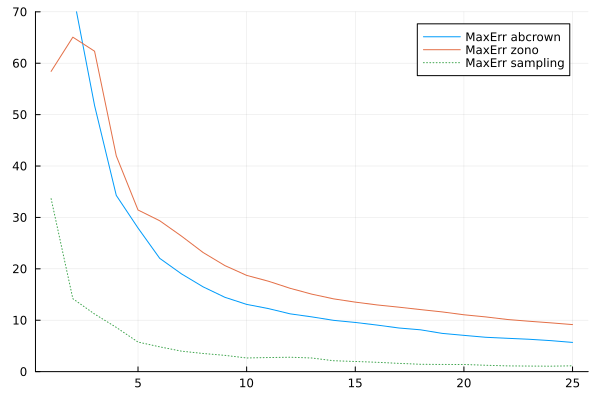

In [73]:
plot(degrees, result_dict["relu_2e5_abcrown"].max_errs, label="MaxErr abcrown")
plot!(degrees, result_dict["relu_2e5_zono"].max_errs, label="MaxErr zono")
plot!(degrees, result_dict["relu_2e5_sampling"].max_errs, label="MaxErr sampling", linestyle=:dot)
ylims!(0, 70)

### Compare ReLU vs GeLU

In [93]:
degrees = 1:25

1:25

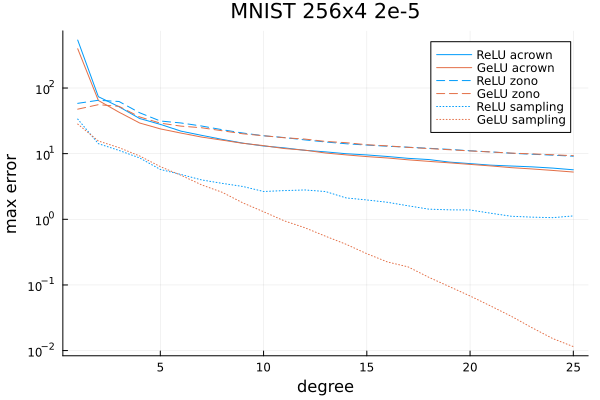

In [94]:
plot(degrees, result_dict["relu_2e5_abcrown"].max_errs, label="ReLU acrown", color=1, yscale=:log10, title="MNIST 256x4 2e-5", xlabel="degree", ylabel="max error")
plot!(degrees, result_dict["gelu_2e5_abcrown"].max_errs, label="GeLU acrown", color=2)

plot!(degrees, result_dict["relu_2e5_zono"].max_errs, label="ReLU zono", color=1, linestyle=:dash)
plot!(degrees, result_dict["gelu_2e5_zono"].max_errs, label="GeLU zono", color=2, linestyle=:dash)

plot!(degrees, result_dict["relu_2e5_sampling"].max_errs, label="ReLU sampling", color=1, linestyle=:dot)
plot!(degrees, result_dict["gelu_2e5_sampling"].max_errs, label="GeLU sampling", color=2, linestyle=:dot)